RavenStack is a B2B SaaS platform. Over the last few quarters, there has been an increase in subscription cancellations. Task is to identify where, when and why customers are leaving, and to provide specific recommendations to the product team.

Questions for analysis:

1. What is the overall churn rate? How is it distributed across plans (plan_tier) and industries?
2. At what stage of the subscription do customers most often leave — within the first 30 days, between 30 and 90 days, or later?
3. What are the most common reasons for cancellation (reason_code)? Is there a link between the reason and the plan?
4. Does feature usage affect churn? Which features’ users are less likely to leave?
5. Is there a link between support quality (satisfaction_score, resolution_time) and churn?

# Imports

In [1]:
from traceback import print_tb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df_accounts = pd.read_csv(r"D:\Downloads\ravenstack_accounts.csv")
df_churn_events = pd.read_csv(r"D:\Downloads\ravenstack_churn_events.csv")
df_feature_usage = pd.read_csv(r"D:\Downloads\ravenstack_feature_usage.csv")
df_subscriptions = pd.read_csv(r"D:\Downloads\ravenstack_subscriptions.csv")
df_support_tickets = pd.read_csv(r"D:\Downloads\ravenstack_support_tickets.csv")

# EDA

In [3]:
print(df_accounts.shape)
print("\n==============================================")
print(df_accounts.dtypes)
print("\n==============================================")

display(df_accounts.head())
print("\n==============================================")
print(df_accounts.info())


(500, 10)

account_id           str
account_name         str
industry             str
country              str
signup_date          str
referral_source      str
plan_tier            str
seats              int64
is_trial            bool
churn_flag          bool
dtype: object



,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB
None


In [4]:
print(df_churn_events.shape)
print("\n==============================================")
print(df_churn_events.dtypes)
print("\n==============================================")

display(df_churn_events.head())
print("\n==============================================")
print(df_churn_events.info())

(600, 9)

churn_event_id                  str
account_id                      str
churn_date                      str
reason_code                     str
refund_amount_usd           float64
preceding_upgrade_flag         bool
preceding_downgrade_flag       bool
is_reactivation                bool
feedback_text                   str
dtype: object



,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive



<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    str    
 1   account_id                600 non-null    str    
 2   churn_date                600 non-null    str    
 3   reason_code               600 non-null    str    
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    str    
dtypes: bool(3), float64(1), str(5)
memory usage: 30.0 KB
None


In [5]:
print(df_feature_usage.shape)
print("\n==============================================")
print(df_feature_usage.dtypes)
print("\n==============================================")

display(df_feature_usage.head())
print("\n==============================================")
print(df_feature_usage.info())

(25000, 8)

usage_id                 str
subscription_id          str
usage_date               str
feature_name             str
usage_count            int64
usage_duration_secs    int64
error_count            int64
is_beta_feature         bool
dtype: object



,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   usage_id             25000 non-null  str  
 1   subscription_id      25000 non-null  str  
 2   usage_date           25000 non-null  str  
 3   feature_name         25000 non-null  str  
 4   usage_count          25000 non-null  int64
 5   usage_duration_secs  25000 non-null  int64
 6   error_count          25000 non-null  int64
 7   is_beta_feature      25000 non-null  bool 
dtypes: bool(1), int64(3), str(4)
memory usage: 1.4 MB
None


In [6]:
print(df_subscriptions.shape)
print("\n==============================================")
print(df_subscriptions.dtypes)
print("\n==============================================")

display(df_subscriptions.head())
print("\n==============================================")
print(df_subscriptions.info())

(5000, 14)

subscription_id        str
account_id             str
start_date             str
end_date               str
plan_tier              str
seats                int64
mrr_amount           int64
arr_amount           int64
is_trial              bool
upgrade_flag          bool
downgrade_flag        bool
churn_flag            bool
billing_frequency      str
auto_renew_flag       bool
dtype: object



,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 376.1 KB
None


In [7]:
print(df_support_tickets.shape)
print("\n==============================================")
print(df_support_tickets.dtypes)
print("\n==============================================")

display(df_support_tickets.head())
print("\n==============================================")
print(df_support_tickets.info())

(2000, 9)

ticket_id                          str
account_id                         str
submitted_at                       str
closed_at                          str
resolution_time_hours          float64
priority                           str
first_response_time_minutes      int64
satisfaction_score             float64
escalation_flag                   bool
dtype: object



,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False



<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   str    
 1   account_id                   2000 non-null   str    
 2   submitted_at                 2000 non-null   str    
 3   closed_at                    2000 non-null   str    
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   str    
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(5)
memory usage: 127.1 KB
None


## Data preparation

1. Renaming columns
2. Type conversion
3. Handling null values
4. Removing duplicates

In [8]:
df_accounts['signup_date'] = pd.to_datetime(df_accounts['signup_date'])

df_churn_events['churn_date'] = pd.to_datetime(df_churn_events['churn_date'])

df_feature_usage['usage_date'] = pd.to_datetime(df_feature_usage['usage_date'])

df_subscriptions['start_date'] = pd.to_datetime(df_subscriptions['start_date'])
df_subscriptions['end_date'] = pd.to_datetime(df_subscriptions['end_date'])

df_support_tickets['submitted_at'] = pd.to_datetime(df_support_tickets['submitted_at'])
df_support_tickets['closed_at'] = pd.to_datetime(df_support_tickets['closed_at'])


In [9]:
dataset_nulls = {
    "Account": df_accounts,
    "Churn Events": df_churn_events,
    "Feature Usage": df_feature_usage,
    "Subscriptions": df_subscriptions,
    "Support Ticket": df_support_tickets
}

for name, df in dataset_nulls.items():
    null_counts = df.isna().sum()
    total_nulls = null_counts.sum()
    total_rows = len(df)

    print(f"\n====== {name.upper()} ======")
    print(f"Total rows: {total_rows}")
    print(f"Null rows: {total_nulls}")

    print(null_counts)

    if total_nulls > 0:
        display(null_counts[null_counts > 0])
    else:
        print("No null rows found.")


====== ACCOUNT ======
Total rows: 500
Null rows: 0
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64
No null rows found.

====== CHURN EVENTS ======
Total rows: 600
Null rows: 148
churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64


feedback_text    148
dtype: int64


====== FEATURE USAGE ======
Total rows: 25000
Null rows: 0
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64
No null rows found.

====== SUBSCRIPTIONS ======
Total rows: 5000
Null rows: 4514
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64


end_date    4514
dtype: int64


====== SUPPORT TICKET ======
Total rows: 2000
Null rows: 825
ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                        0
resolution_time_hours            0
priority                         0
first_response_time_minutes      0
satisfaction_score             825
escalation_flag                  0
dtype: int64


satisfaction_score    825
dtype: int64

In [10]:
df_churn_events['feedback_text'] = df_churn_events['feedback_text'].fillna('No feedback')

df_subscriptions['is_active'] = df_subscriptions['end_date'].isna()

df_support_tickets['satisfaction_score'] = df_support_tickets['satisfaction_score'].fillna(df_support_tickets['satisfaction_score'].median())

print(df_subscriptions['is_active'].value_counts())
print(df_subscriptions['churn_flag'].value_counts())

is_active
True     4514
False     486
Name: count, dtype: int64
churn_flag
False    4514
True      486
Name: count, dtype: int64


In [11]:
datasets_duplicates = {
    "Account": df_accounts,
    "Churn Events": df_churn_events,
    "Feature Usage": df_feature_usage,
    "Subscriptions": df_subscriptions,
    "Support Ticket": df_support_tickets
}

for name, df in datasets_duplicates.items():
    duplicates = df.duplicated().sum()
    total_rows = len(df)

    print(f"\n====== {name.upper()} ======")
    print(f"Total rows: {total_rows}")
    print(f"Duplicate rows: {duplicates}")

    if duplicates > 0:
        display(df[df.duplicated()])
    else:
        print("No duplicates found.")


====== ACCOUNT ======
Total rows: 500
Duplicate rows: 0
No duplicates found.

====== CHURN EVENTS ======
Total rows: 600
Duplicate rows: 0
No duplicates found.

====== FEATURE USAGE ======
Total rows: 25000
Duplicate rows: 0
No duplicates found.

====== SUBSCRIPTIONS ======
Total rows: 5000
Duplicate rows: 0
No duplicates found.

====== SUPPORT TICKET ======
Total rows: 2000
Duplicate rows: 0
No duplicates found.


## What is the overall churn rate? How does it break down by plan tier and industry?

In [12]:
total_accounts = len(df_accounts)
churned = df_accounts['churn_flag'].sum()

overall_churn_rate = churned / total_accounts
print(f"\n=== Q1: Overall Churn Rate ===")
print(f"Total accounts : {total_accounts}")
print(f"Churned : {churned}")
print(f"Churn Rate : {overall_churn_rate:.1%}")

churn_rate_by_plan = (
    df_accounts
    .groupby('plan_tier')['churn_flag']
    .agg(
        total = 'size',
        churned = 'sum',
    )
    .assign(churn_rate = lambda x: x['churned'] * 100.0 / x['total']).round(1)
    .sort_values(by = 'churn_rate', ascending = False)
)

print("\nChurn Rate By Plan:")
print(churn_rate_by_plan)

churn_rate_by_industry = (
    df_accounts
    .groupby('industry')['churn_flag']
    .agg(
        total = 'size',
        churned = 'sum',
    )
    .assign(churn_rate = lambda x: x['churned'] * 100.0 / x['total']).round(1)
    .sort_values(by = 'churn_rate', ascending = False)
)

print("\nChurn Rate By Industry:")
print(churn_rate_by_industry)


=== Q1: Overall Churn Rate ===
Total accounts : 500
Churned : 110
Churn Rate : 22.0%

Churn Rate By Plan:
            total  churned  churn_rate
plan_tier                             
Enterprise    154       34        22.1
Basic         168       37        22.0
Pro           178       39        21.9

Churn Rate By Industry:
               total  churned  churn_rate
industry                                 
DevTools         113       35        31.0
FinTech          112       25        22.3
HealthTech        96       21        21.9
EdTech            79       13        16.5
Cybersecurity    100       16        16.0


In [13]:
months = pd.period_range(
    df_churn_events['churn_date'].min(),
    df_churn_events['churn_date'].max(),
    freq = 'M'
)

rows = []
for month in months:
    month_start = month.start_time
    month_end = month.end_time

    active = df_subscriptions[
        (df_subscriptions['start_date'] <= month_start) &
        (df_subscriptions['end_date'].isna() | (df_subscriptions['end_date'] >= month_start))
    ]['account_id'].nunique()

    churned = df_churn_events[
        (df_churn_events['churn_date'] >= month_start) &
        (df_churn_events['churn_date'] <= month_end)
    ]['account_id'].nunique()

    rows.append({
        'month': month,
        'active': active,
        'churned': churned,
        'churn_rate': churned / active  * 100.0 if active > 0 else 0,
    })

monthly_churn = pd.DataFrame(rows)
print(monthly_churn)

      month  active  churned  churn_rate
0   2023-01       0        1    0.000000
1   2023-02       2        0    0.000000
2   2023-03      10        5   50.000000
3   2023-04      21        3   14.285714
4   2023-05      37        3    8.108108
5   2023-06      50        5   10.000000
6   2023-07      71        6    8.450704
7   2023-08      90        6    6.666667
8   2023-09     117        6    5.128205
9   2023-10     131       10    7.633588
10  2023-11     149       11    7.382550
11  2023-12     172       16    9.302326
12  2024-01     191       18    9.424084
13  2024-02     216       10    4.629630
14  2024-03     235       24   10.212766
15  2024-04     264       23    8.712121
16  2024-05     282       25    8.865248
17  2024-06     313       38   12.140575
18  2024-07     338       33    9.763314
19  2024-08     366       40   10.928962
20  2024-09     385       48   12.467532
21  2024-10     415       60   14.457831
22  2024-11     441       60   13.605442
23  2024-12     

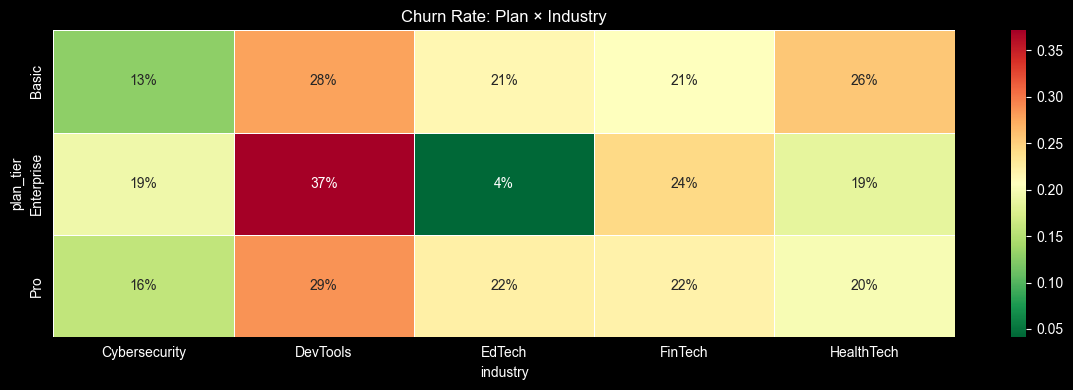

In [14]:
pivot = (
    df_accounts
    .groupby(['plan_tier', 'industry'])['churn_flag']
    .mean()
    .unstack('industry')
)
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', ax=ax, linewidths=.5)
ax.set_title('Churn Rate: Plan × Industry')
plt.tight_layout()
plt.show()

The highest churn rate is observed in the Enterprise + DevTools segment (37%), which may indicate that the product is failing to meet the expectations of large clients in this industry. The unusually low churn rate in Enterprise + EdTech (4%) warrants separate analysis as a potential success story. The DevTools industry consistently shows high churn across all plans, whereas Cybersecurity is the segment with the highest retention.

## Churned Monthly

In [18]:
df_churn_events['month'] = df_churn_events['churn_date'].dt.to_period('M')

churned_monthly = (
    df_churn_events.merge(
        df_accounts[['account_id', 'plan_tier']],
        on = 'account_id',
        how = 'left',
    )
    .groupby(['month', 'plan_tier'])['account_id']
    .nunique()
    .reset_index(name='churned')
)

In [19]:
months = pd.period_range(df_churn_events['churn_date'].min(), df_churn_events['churn_date'].max(), freq='M')

rows = []
for month in months:
    month_start = month.start_time

    active = (
        df_subscriptions[
            (df_subscriptions['start_date'] < month_start) &
            (df_subscriptions['end_date'].isna() | (df_subscriptions['end_date'] >= month_start))
        ]
        .groupby('plan_tier')['account_id']
        .nunique()
        .reset_index(name='active')
    )
    active['month'] = month
    rows.append(active)

active_monthly = pd.concat(rows, ignore_index=True)

In [20]:
monthly_churn = (
    active_monthly
    .merge(churned_monthly, on=['month', 'plan_tier'], how='left')
    .assign(
        churned=lambda x: x['churned'].fillna(0),
        churn_rate=lambda x: x['churned'] / x['active'],
        month_str=lambda x: x['month'].astype(str)
    )
)

print(monthly_churn[['month_str', 'plan_tier', 'active', 'churned', 'churn_rate']])

   month_str   plan_tier  active  churned  churn_rate
0    2023-02       Basic       1      0.0    0.000000
1    2023-02  Enterprise       1      0.0    0.000000
2    2023-02         Pro       1      0.0    0.000000
3    2023-03       Basic       4      1.0    0.250000
4    2023-03  Enterprise       3      2.0    0.666667
..       ...         ...     ...      ...         ...
64   2024-11  Enterprise     398     21.0    0.052764
65   2024-11         Pro     384     16.0    0.041667
66   2024-12       Basic     424     30.0    0.070755
67   2024-12  Enterprise     437     31.0    0.070938
68   2024-12         Pro     418     35.0    0.083732

[69 rows x 5 columns]


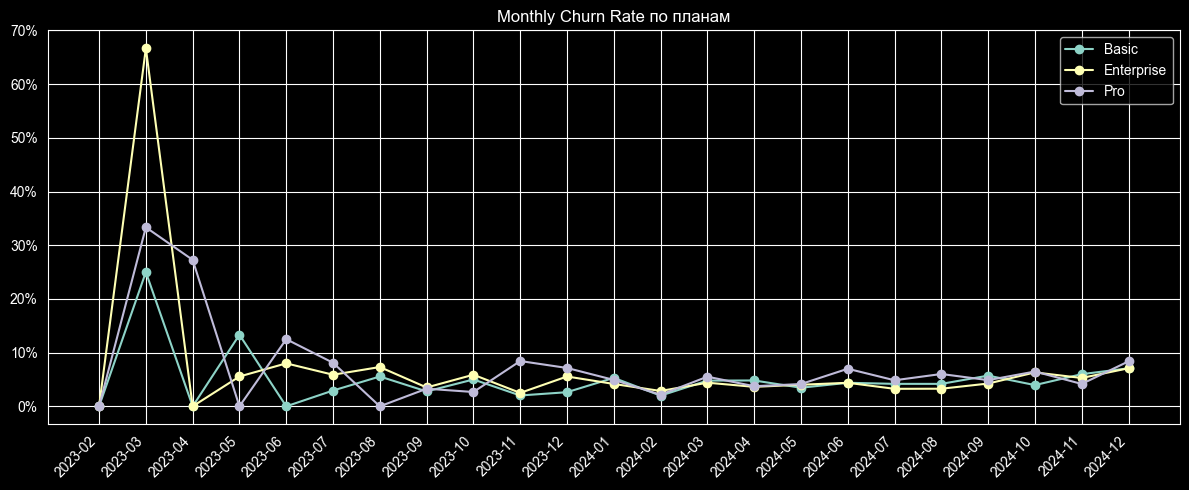

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

for plan in monthly_churn['plan_tier'].unique():
    data = monthly_churn[monthly_churn['plan_tier'] == plan]
    ax.plot(data['month_str'], data['churn_rate'], marker='o', label=plan)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Monthly Churn Rate по планам')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusion: The initial peaks are not indicative due to the small sample size. The actual monthly churn rate has remained stable at 3–6% across all plans since mid-2023.

## 2. At which stage of the subscription do customers most often cancel—within the first 30 days, between 30 and 90 days, or later?

In [ ]:
first_churns = df_churn_events[df_churn_events['is_reactivation'] == 0]

In [ ]:
first_sub = (
    df_subscriptions
    .groupby('account_id')['start_date']
    .min()
    .reset_index()
    .rename(columns={'start_date': 'first_sub_date'})
)

In [ ]:
churn_lifecycle = first_churns.merge(first_sub, on='account_id', how='left')

churn_lifecycle['days_to_churn'] = (
    churn_lifecycle['churn_date'] - churn_lifecycle['first_sub_date']
).dt.days

bins = [30, 60, 90, float('inf')]
labels = ['< 30 days', '30-90 days', '> 90 days']

churn_lifecycle['stage'] = pd.cut(
    churn_lifecycle['days_to_churn'],
    bins=bins,
    labels=labels,
)

In [ ]:
stage_dist = (
    churn_lifecycle['stage']
    .value_counts(normalize=True)
    .sort_index()
)

print(stage_dist.map('{:.1%}'.format))
print("====================================")
print(churn_lifecycle[['account_id', 'churn_date', 'first_sub_date', 'days_to_churn']].head(10))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
stage_dist.plot(kind='bar', ax=ax, color=['red', 'yellow', 'green'])
ax.set_title('Churn Lifecycle Distribution')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The main churn occurs among “mature” customers (those who have been with us for over 90 days), but early churn (those who leave within 30 days) is also significant and warrants attention - this is most likely an onboarding issue.


## 3. What are the most common reasons for cancellation (reason_code)? Is there a link between the reason and the plan?


In [ ]:
top_reasons = (
    df_churn_events['reason_code']
    .value_counts(normalize=True)
    .sort_values(ascending=True)
)
print(top_reasons.map('{:.1%}'.format))

In [ ]:
churn_with_plan = df_churn_events.merge(df_accounts[['account_id', 'plan_tier']], on='account_id', how='left')

reason_plan = pd.crosstab(
    churn_with_plan['reason_code'],
    churn_with_plan['plan_tier'],
    normalize='columns',
)
print(reason_plan.round(2))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=top_reasons.reset_index(),
    x='proportion',
    y='reason_code',
    ax=axes[0],
    orient='h'
)

axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_title('Top Churn Reason')
axes[0].set_xlabel('')

sns.heatmap(reason_plan, annot=True, fmt='.0%', cmap='RdYlGn_r', ax=axes[1], linewidths=.5)
axes[1].set_title('Churn Reason to Plan')

plt.tight_layout()
plt.show()

It is worth noting that the 16% marked as ‘unknown’ may belong to the higher-priced customer segment, as their proportion is higher—14% for Basic, 18% for Enterprise and 16% for Pro. Customers in the higher-priced segment are also less likely to cite support issues.
By subscription tier, three main reasons for cancellation can be identified: support, features and budget. The highest number of cancellations is attributed to reasons related to features, with the cancellation rate being quite high across all subscription tiers: 19% for Basic, 20% for Enterprise and 18% for Pro.
 In second place is the reason related to support: 21% for Basic and 19% for Pro, whilst Enterprise is in the green zone at 12%. Budget is distributed evenly across all three plans and varies between 17% and 18%.
 It is recommended to review support for the Basic and Pro tiers, as well as to further review and improve the implementation of new features and support for existing ones across all plans.


## 4. Does feature usage affect churn? Which features users are less likely to leave?


In [ ]:
usage_with_acc = df_feature_usage.merge(
    df_subscriptions[['subscription_id', 'account_id']],
    on='subscription_id',
    how='left'
)

usage_with_acc = usage_with_acc.merge(
    df_accounts[['account_id', 'churn_flag']],
    on='account_id',
    how='left'
)


In [ ]:
usage_deduped = usage_with_acc.drop_duplicates(subset=['account_id', 'feature_name'])

In [ ]:
affected_feature = (
    usage_deduped
    .groupby('feature_name')['churn_flag']
    .agg(
        total='count',
        churned='sum'
    )
    .assign(churn_rate = lambda x: x['churned'] / x['total'])
    .sort_values(by='churn_rate', ascending=False)
)

print(affected_feature.head(10))

In [ ]:
print("Features with the lowest churn rate (retention):")
print(affected_feature.tail(5))

print("\nFeatures with the highest churn rate:")
print(affected_feature.head(5))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))


sns.barplot(
    data=affected_feature.reset_index(),
    x='churn_rate',
    y='feature_name',
    ax=ax,
    orient='h'
)

ax.axvline(
    df_accounts['churn_flag'].mean(),
    color='red',
    linestyle='--',
    label='Mean churn rate'
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Features Churn Rate')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

Сancellations are not linked to features – the statistics are consistent and the variation is minimal. The average cancellation rate is ~22%, with a minimum of 20% for feature_16 and a maximum of 25% for feature_37. No clear triggers or features that retain customers have been identified.


## 5. Is there a link between support quality (satisfaction_score, resolution_time) and churn?


In [ ]:
support_churn = df_support_tickets.merge(
    df_accounts[['account_id', 'churn_flag']],
    on='account_id',
)

print(f"Before: {len(df_support_tickets)}")
print(f"After: {len(support_churn)}")

In [ ]:
support_summary = (
    support_churn
    .groupby('churn_flag')
    .agg(
        avg_satisfaction = ('satisfaction_score', 'mean'),
        avg_resolution_time = ('resolution_time_hours', 'mean'),
        avg_first_response = ('first_response_time_minutes', 'mean'),
        escalation_rate = ('escalation_flag', 'mean'),
    ).reset_index()
)

support_summary['churn_flag'] = support_summary['churn_flag'].map({True: 'Churned', False: 'Retained'})
display(support_summary)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('avg_satisfaction', 'Avg Satisfaction Score'),
    ('avg_resolution_time', 'Avg Resolution Time (hrs)'),
    ('avg_first_response', 'Avg First Response (min)')
]

for ax, (col, title) in zip(axes, metrics):
    ax.bar(
        support_summary['churn_flag'],
        support_summary[col],
        color=['#DD8452', '#4C72B0']
    )
    ax.set_title(title)
    ax.set_xlabel('Segment')

plt.tight_layout()
plt.show()

The quality of support has no significant impact on churn. The average satisfaction score is virtually identical for retained and churned customers (~4.0), and there is also no noticeable difference between the groups in terms of resolution time and first response time. No correlation has been found between the quality of support and churn.

# Overall

The highest churn rate is observed in the ‘Enterprise + DevTools’ segment (37%); specifically, the DevTools sector shows a consistently high churn rate across all pricing plans. The ‘Cybersecurity’ segment demonstrates the highest customer retention rate. The ‘Enterprise + EdTech’ segment (4%) deserves special attention as a potentially successful retention strategy.
The main churn is concentrated among mature customers - those who have been subscribed for more than 90 days (70%). At the same time, one in five customers (18.5%) leaves within the first 30 days, which may indicate onboarding issues.
‘Features’ (19%) and ‘support’ (17%) stand out slightly among the reasons for cancellations, though the variation between reasons is minimal. When broken down by plan, it is worth noting the high support rate for Basic (21%) and Pro (19%) compared to the low rate for Enterprise (12%).
Subscription cancellations are not linked to specific features - the churn rate across all 40 features varies within a narrow range of 20–25%. The quality of support also has no significant impact on churn - the satisfaction score is virtually identical for retained and churned customers (~4.0).
Recommendations:
- Review the retention strategy in the ‘Enterprise + DevTools’ segment and study ‘Enterprise + EdTech’ as an example of successful retention.
- Analyse the onboarding process — there may be difficulties in getting to grips with the product at the outset.
- Review support at the Basic and Pro levels: check the team’s workload and whether they are overloaded.
- Further analyse the product’s features to ensure they meet customer expectations.